In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to your data
file_path = os.path.join('..', 'data', 'nigeria.csv')

# Load and prepare the date index
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df.set_index('Date', inplace=True)

# Preview the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
Date,,,,,,,,,,,,
2015-01-01,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
2015-01-02,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2015-01-03,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
2015-01-04,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
2015-01-05,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
# Check for missing values
print("Missing Values Check - Nigeria:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary - Nigeria:")
display(df.describe())

Missing Values Check - Nigeria:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Statistical Summary - Nigeria:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000


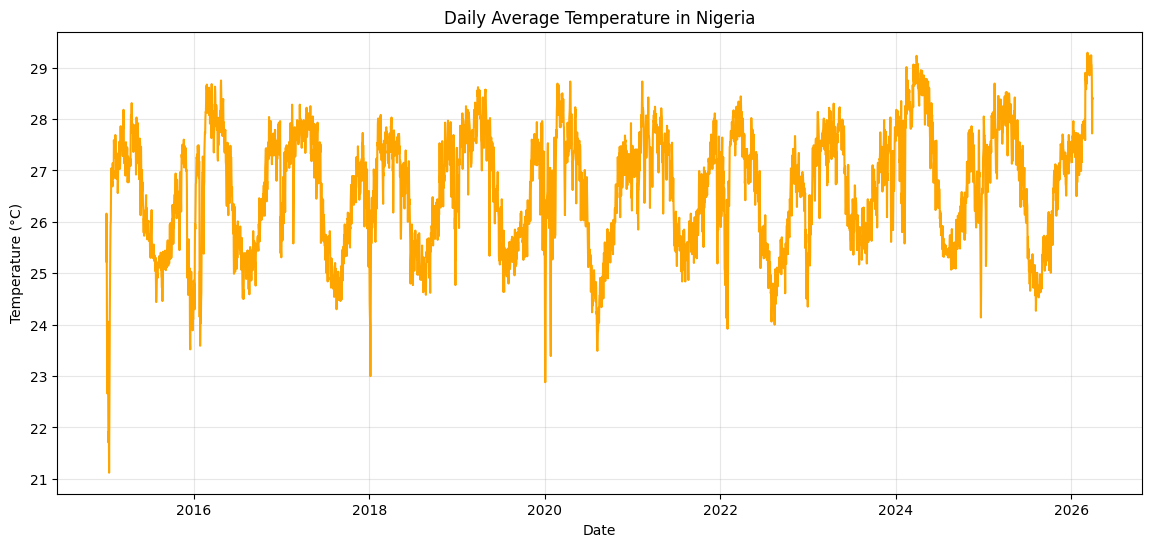

In [4]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='T2M', color='orange')
plt.title('Daily Average Temperature in Nigeria')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

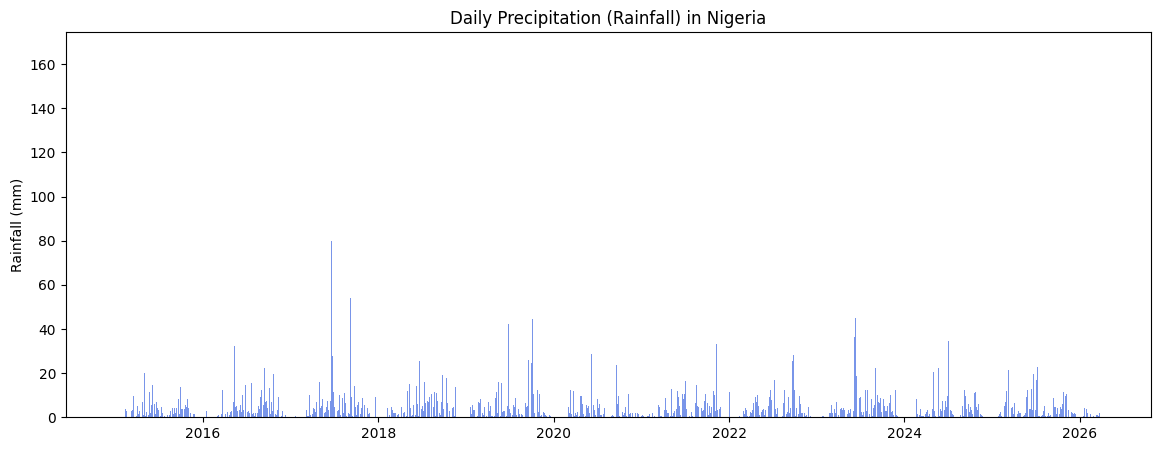

In [8]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['PRECTOTCORR'], color='royalblue', alpha=0.7)
plt.title('Daily Precipitation (Rainfall) in Nigeria')
plt.ylabel('Rainfall (mm)')
plt.show()

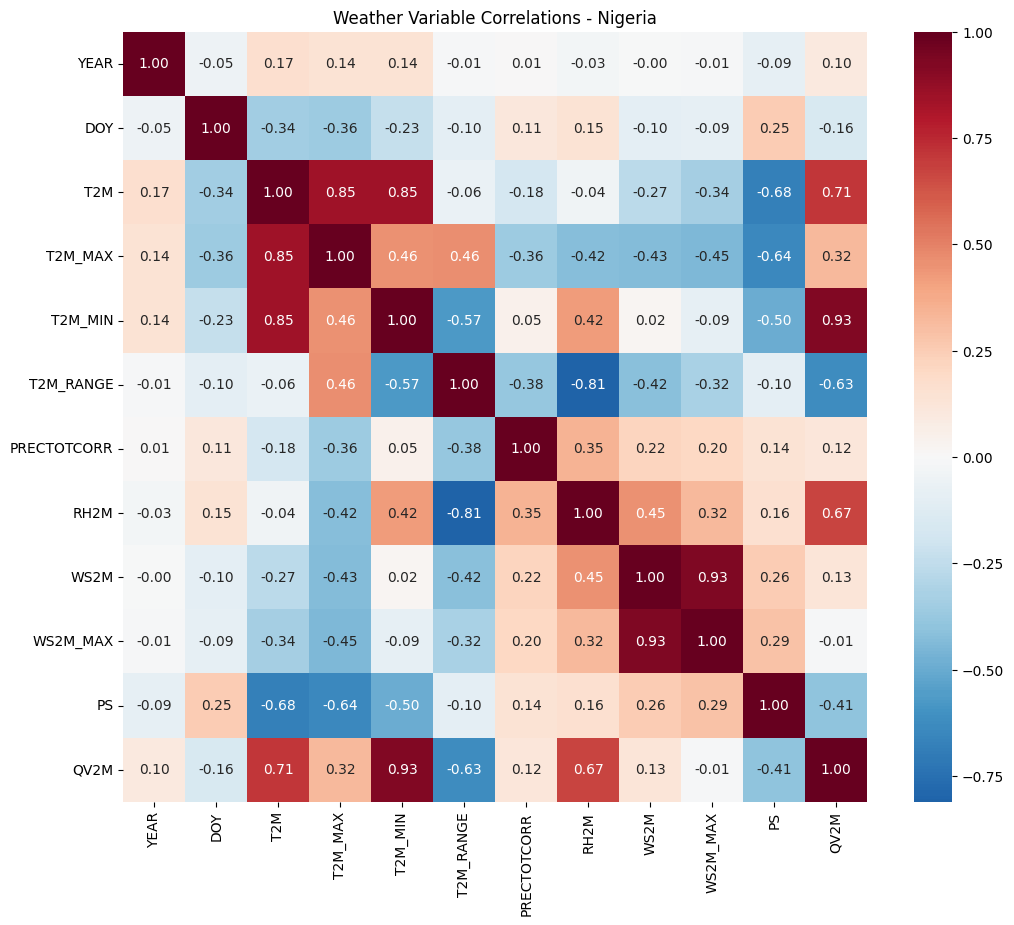

In [7]:
plt.figure(figsize=(12, 10))
# We calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Weather Variable Correlations - Nigeria')
plt.show()

In [9]:
import numpy as np
from scipy import stats

# 1. Load and add Country column
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'

# 2. Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

# 3. Handle NASA Sentinel values (-999)
df.replace(-999, np.nan, inplace=True)

# 4. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. Missing value report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct)

Duplicates found: 0

Missing Values Percentage:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Month          0.0
dtype: float64


In [10]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging rows where Z > 3
outliers = (z_scores > 3).all(axis=1)
print(f"Number of outlier rows flagged in Nigeria: {outliers.sum()}")

# Decision: We will retain them for now as weather extremes (like heavy rain) 
# are important for climate study, but we acknowledge them.

Number of outlier rows flagged in Nigeria: 0


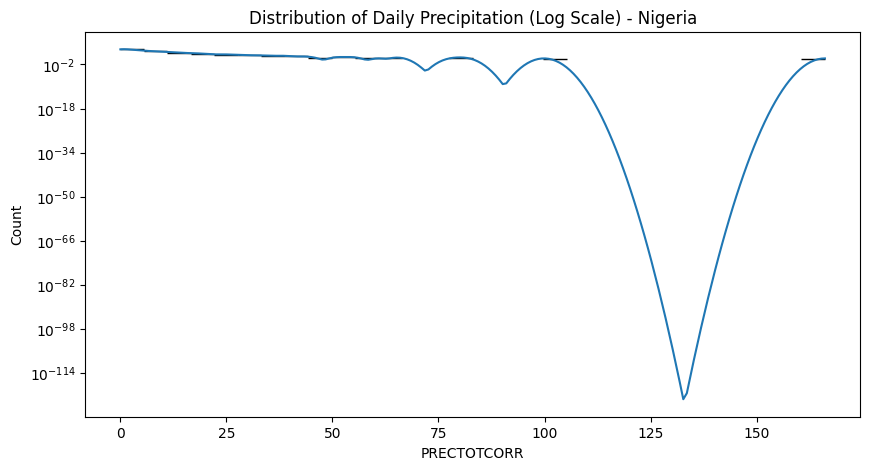

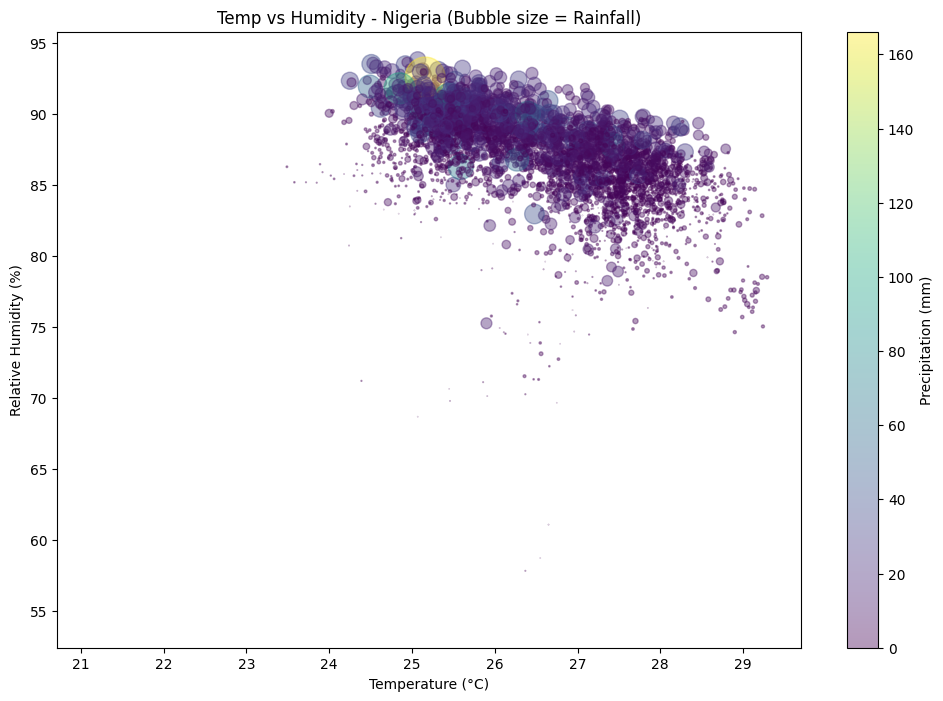

In [11]:
# Histogram of Rainfall (Log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale) - Nigeria')
plt.show()

# Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temp vs Humidity - Nigeria (Bubble size = Rainfall)')
plt.show()

In [12]:
# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Export
df.to_csv('../data/nigeria_clean.csv')
print("Cleaned data exported to data/nigeria_clean.csv")

Cleaned data exported to data/nigeria_clean.csv


Final Analysis: 
Nigeria Climate Trends
The Trend: Nigeria exhibits a very stable but high-temperature profile, with a mean of 26.66°C. The temperature range is much tighter than in Ethiopia or Kenya (mean range of only 4°C), indicating a consistent tropical climate. The line plot shows regular seasonal cycles with no significant long-term deviation, though the baseline remains consistently warm.

The Connection: Rainfall in Nigeria is moderately correlated with Relative Humidity (RH2M) at 0.35. Interestingly, there is a negative correlation with T2M_MAX (-0.36), suggesting that the heaviest rain days occur when peak daily temperatures are slightly suppressed, likely due to heavy cloud cover and the cooling effect of intense precipitation.

The Outliers: The Z-score check flagged 0 rows for total dataset outliers. However, the maximum precipitation of 166.10mm is a massive statistical extreme compared to the mean of 4.21mm. This represents extreme monsoon-level events. We retain these values as they are the most critical data points for flood modeling and urban drainage planning in Nigerian coastal and inland cities.